# Detección de fallas en barras del rotor (BRB)
Análisis espectral de la corriente del estator mediante FFT, Welch y filtrado pasabanda.

## Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.signal import butter, sosfiltfilt
from scipy.signal import sosfreqz
from scipy.stats import kurtosis, skew

## 1. Introducción
Se analiza la corriente del estator de un motor de inducción trifásico para detectar fallas por barras rotas del rotor (BRB), comparando cuatro condiciones: motor sano (Healthy), 1, 2 y 3 barras rotas.

Las asimetrías que genera la falla aparecen como bandas laterales alrededor de la frecuencia fundamental (50 Hz), por lo que el análisis se enfoca en el dominio de la frecuencia (FFT y Welch), seguido de un filtrado pasabanda y la extracción de características que cuantifiquen esas bandas.

## 2. Carga de datos
Se leen las hojas H, 1B, 2B y 3B del archivo Excel, correspondientes a cada condición del motor, y se extraen las corrientes de las tres fases (A, B, C).

In [34]:
archivo = "M24Ns_29Nb.xlsx"

df_H = pd.read_excel(archivo, sheet_name="H", header=None)
df_1B = pd.read_excel(archivo, sheet_name="1B", header=None)
df_2B = pd.read_excel(archivo, sheet_name="2B", header=None)
df_3B = pd.read_excel(archivo, sheet_name="3B", header=None)

Fs = 2000

In [35]:
# FASE A
A_H = df_H.iloc[:,1].values
A_1B = df_1B.iloc[:,1].values
A_2B = df_2B.iloc[:,1].values
A_3B = df_3B.iloc[:,1].values

# FASE B
B_H = df_H.iloc[:,2].values
B_1B = df_1B.iloc[:,2].values
B_2B = df_2B.iloc[:,2].values
B_3B = df_3B.iloc[:,2].values

# FASE C
C_H = df_H.iloc[:,3].values
C_1B = df_1B.iloc[:,3].values
C_2B = df_2B.iloc[:,3].values
C_3B = df_3B.iloc[:,3].values

## 3. Visualización temporal
Función auxiliar para graficar las cuatro condiciones (Healthy, 1BRB, 2BRB, 3BRB) superpuestas en el dominio del tiempo.

In [36]:
def plot_phase(t, H, B1, B2, B3, title):
    plt.figure(figsize=(12,5))
    plt.plot(t, H, label="Healthy")
    plt.plot(t, B1, label="1 BRB")
    plt.plot(t, B2, label="2 BRB")
    plt.plot(t, B3, label="3 BRB")
    plt.title(title)
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Corriente")
    plt.grid()
    plt.legend()
    plt.show()

Se grafica la corriente de la fase A (representativa, dado que las tres fases se comportan de forma muy similar) para las cuatro condiciones, incluyendo el transitorio inicial de arranque del motor.

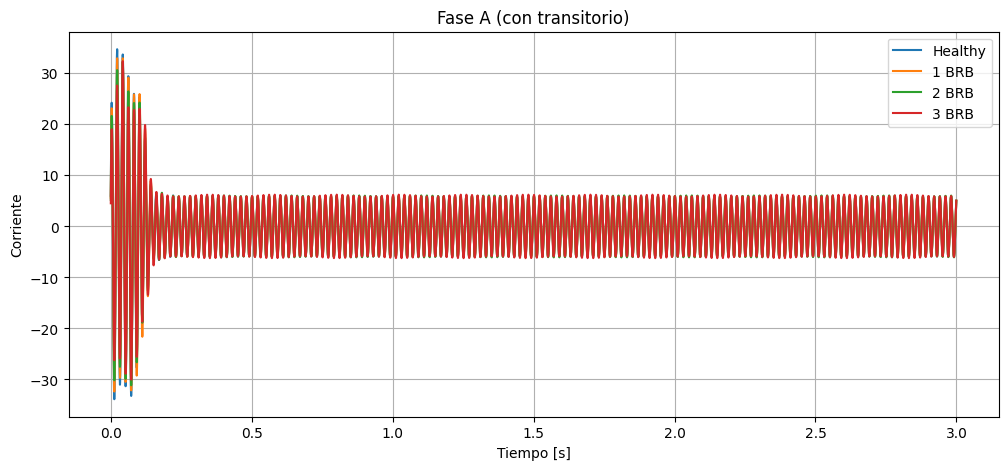

In [37]:
t_full = np.arange(len(A_H)) / Fs
plot_phase(t_full, A_H, A_1B, A_2B, A_3B, "Fase A (con transitorio)")

## 4. Eliminación del transitorio
Se descartan los primeros 0.2 s de cada señal (400 muestras con Fs=2000 Hz) para quedarnos únicamente con el régimen permanente del motor.

In [38]:
start = int(0.2 * Fs)

# FASE A
A_H = A_H[start:]
A_1B = A_1B[start:]
A_2B = A_2B[start:]
A_3B = A_3B[start:]

# FASE B
B_H = B_H[start:]
B_1B = B_1B[start:]
B_2B = B_2B[start:]
B_3B = B_3B[start:]

# FASE C
C_H = C_H[start:]
C_1B = C_1B[start:]
C_2B = C_2B[start:]
C_3B = C_3B[start:]

t = np.arange(len(A_H)) / Fs

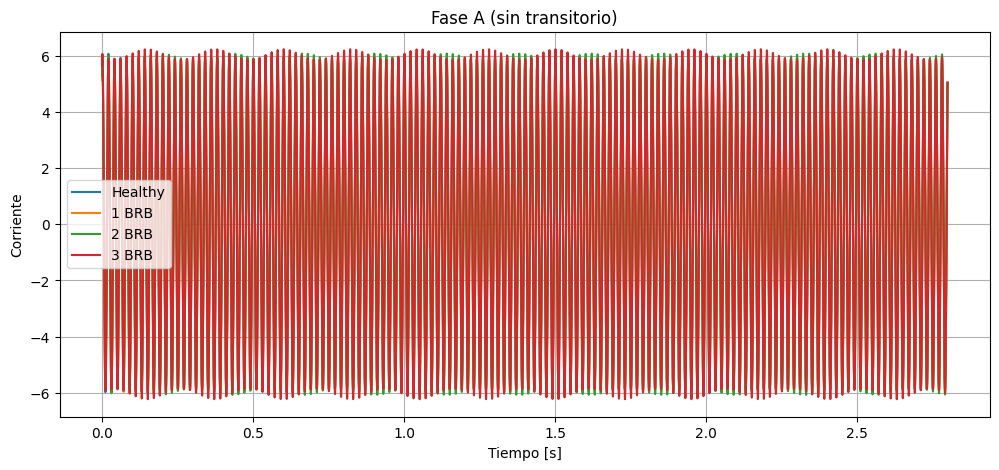

In [39]:
plot_phase(t, A_H, A_1B, A_2B, A_3B, "Fase A (sin transitorio)")

## 5. FFT inicial
`compute_fft` calcula la FFT de una señal: le quita la media, aplica una ventana de Hanning (para reducir fuga espectral) y devuelve solo las frecuencias positivas.

`plot_fft_compare` la usa para graficar las cuatro condiciones juntas en un mismo espectro.

In [40]:
def compute_fft(signal, Fs):
    N = len(signal)
    # quitar media
    signal = signal - np.mean(signal)
    # ventana de Hanning
    window = np.hanning(N)
    signal = signal * window
    fft = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, 1/Fs)
    idx = freqs > 0
    return freqs[idx], np.abs(fft[idx]) / N


def plot_fft_compare(H, B1, B2, B3, Fs, title, xlim=(0, 400)):
    f_H, X_H = compute_fft(H, Fs)
    f_1B, X_1B = compute_fft(B1, Fs)
    f_2B, X_2B = compute_fft(B2, Fs)
    f_3B, X_3B = compute_fft(B3, Fs)

    plt.figure(figsize=(12,5))
    plt.semilogy(f_H, X_H, label="Healthy")
    plt.semilogy(f_1B, X_1B, label="1 BRB")
    plt.semilogy(f_2B, X_2B, label="2 BRB")
    plt.semilogy(f_3B, X_3B, label="3 BRB")
    plt.xlim(xlim)
    plt.title(f"FFT - {title}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Magnitud")
    plt.grid()
    plt.legend()
    plt.show()

Espectro completo (0-400 Hz) de la corriente sin filtrar, para las tres fases.

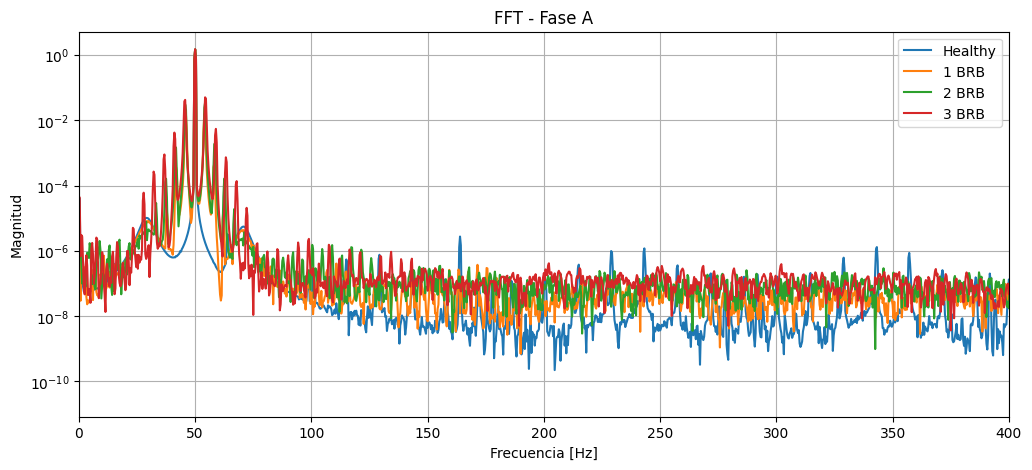

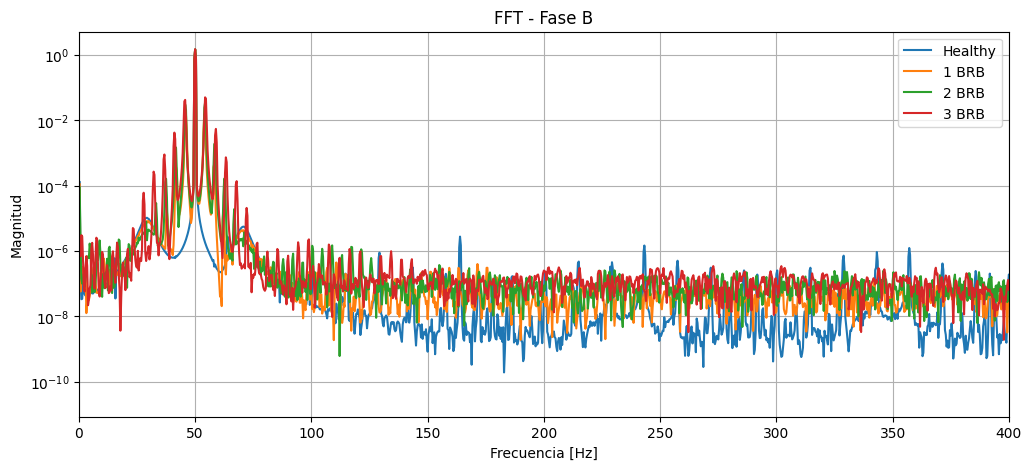

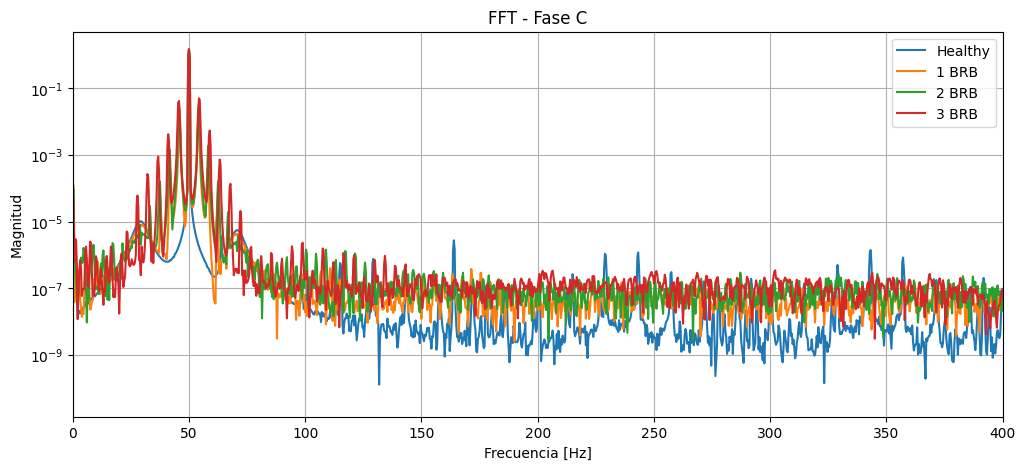

In [41]:
plot_fft_compare(A_H, A_1B, A_2B, A_3B, Fs, "Fase A")
plot_fft_compare(B_H, B_1B, B_2B, B_3B, Fs, "Fase B")
plot_fft_compare(C_H, C_1B, C_2B, C_3B, Fs, "Fase C")

## 6. Welch PSD
`compute_psd` estima la densidad espectral de potencia con el método de Welch (promedia varios segmentos superpuestos), lo que da una estimación más suave y menos ruidosa que la FFT directa.

`plot_psd_compare` grafica esa PSD para las cuatro condiciones.

In [42]:
def compute_psd(signal, Fs):
    signal = signal - np.mean(signal)
    f, Pxx = welch(
        signal,
        fs=Fs,
        window='hann',
        nperseg=2048,
        noverlap=512
    )
    return f, Pxx


def plot_psd_compare(H, B1, B2, B3, Fs, title, xlim=(0, 400)):
    f_H, P_H = compute_psd(H, Fs)
    f_1B, P_1B = compute_psd(B1, Fs)
    f_2B, P_2B = compute_psd(B2, Fs)
    f_3B, P_3B = compute_psd(B3, Fs)

    plt.figure(figsize=(12,5))
    plt.semilogy(f_H, P_H, label="Healthy")
    plt.semilogy(f_1B, P_1B, label="1 BRB")
    plt.semilogy(f_2B, P_2B, label="2 BRB")
    plt.semilogy(f_3B, P_3B, label="3 BRB")
    plt.xlim(xlim)
    plt.title(f"Welch PSD - {title}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Potencia")
    plt.grid()
    plt.legend()
    plt.show()

Densidad espectral de potencia sobre la señal sin filtrar, para las tres fases.

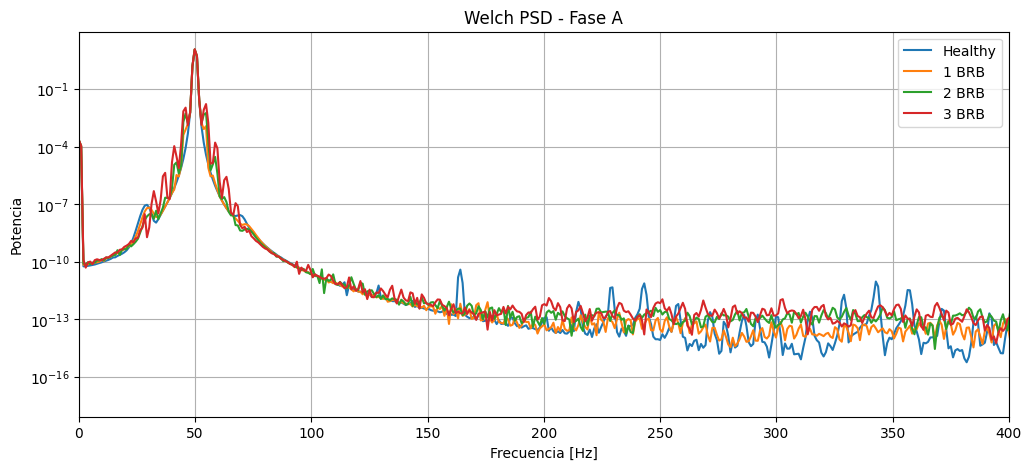

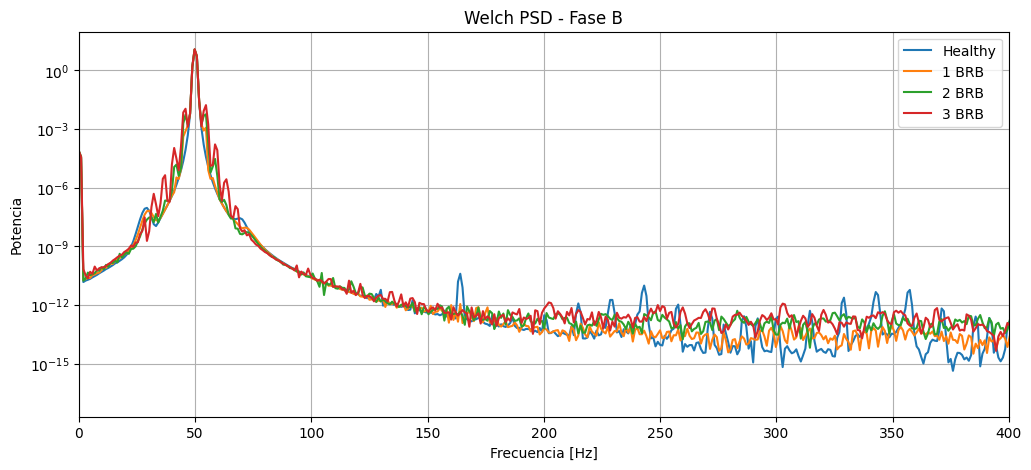

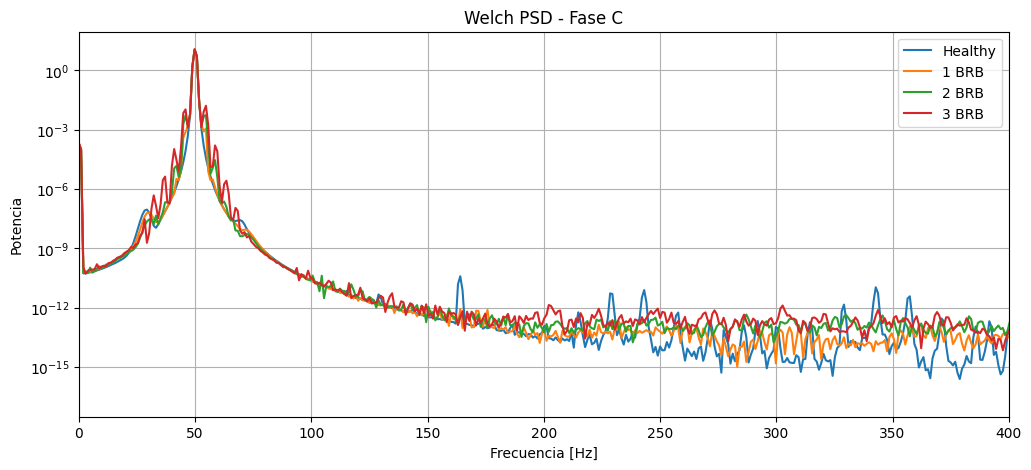

In [43]:
plot_psd_compare(A_H, A_1B, A_2B, A_3B, Fs, "Fase A")
plot_psd_compare(B_H, B_1B, B_2B, B_3B, Fs, "Fase B")
plot_psd_compare(C_H, C_1B, C_2B, C_3B, Fs, "Fase C")

## 7. Zoom en 20-80 Hz
Reutilizamos `plot_fft_compare` y `plot_psd_compare` pero acotando el eje de frecuencias, para ver mejor la banda donde se concentran las diferencias entre condiciones (alrededor de los 50 Hz).

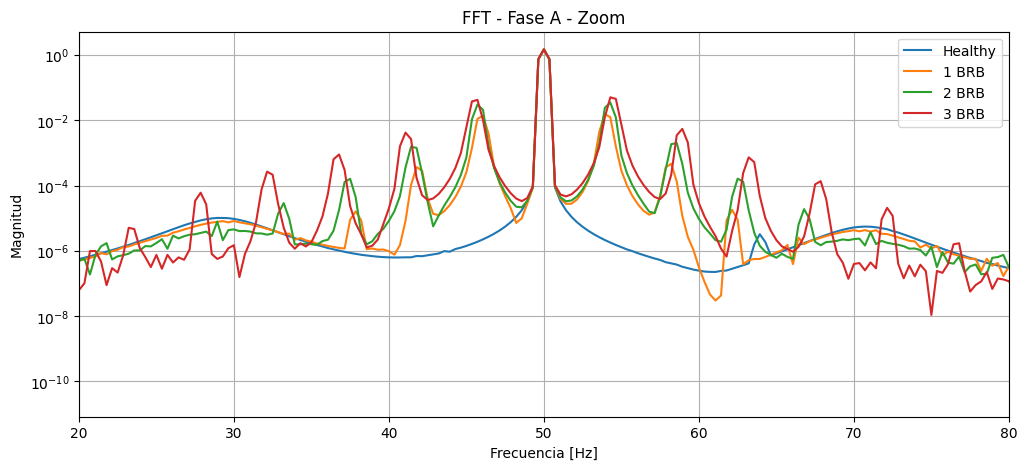

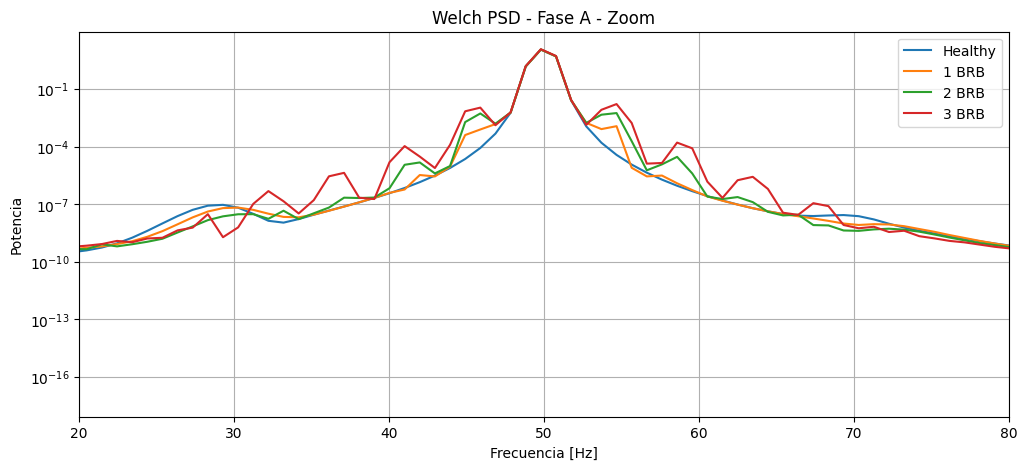

In [44]:
plot_fft_compare(A_H, A_1B, A_2B, A_3B, Fs, "Fase A - Zoom", xlim=(20, 80))
plot_psd_compare(A_H, A_1B, A_2B, A_3B, Fs, "Fase A - Zoom", xlim=(20, 80))

## 8. Diseño del filtro
`bandpass_filter` diseña un filtro Butterworth pasabanda de 20-80 Hz en formato SOS (secciones de segundo orden), que es numéricamente más estable que el formato clásico b,a para filtros de orden alto, y lo aplica a la señal con `sosfiltfilt` (filtrado sin desfasaje).

Antes de aplicarlo, se grafica su respuesta en frecuencia para verificar que la banda pasante sea la esperada.

In [45]:
def bandpass_filter(signal, Fs, lowcut=20, highcut=80, order=2):
    nyquist = Fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    sos = butter(order, [low, high], btype='band', output='sos')
    filtered = sosfiltfilt(sos, signal)
    return filtered

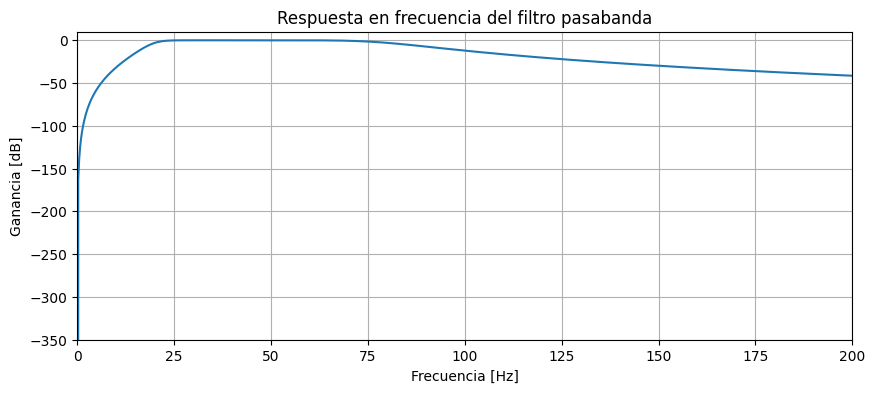

In [46]:
sos = butter(4, [20/(Fs/2), 80/(Fs/2)], btype='band', output='sos')
w, h = sosfreqz(sos, worN=4096)

plt.figure(figsize=(10,4))
plt.plot(w*Fs/(2*np.pi), 20*np.log10(np.abs(h) + 1e-300))
plt.grid()
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Ganancia [dB]")
plt.title("Respuesta en frecuencia del filtro pasabanda")
plt.xlim(0,200)
plt.ylim(-350,10)
plt.show()

## 9. Aplicación del filtro
Se filtran las tres fases, en las cuatro condiciones, con `bandpass_filter`.

In [47]:
# FASE A
A_H_filt = bandpass_filter(A_H, Fs)
A_1B_filt = bandpass_filter(A_1B, Fs)
A_2B_filt = bandpass_filter(A_2B, Fs)
A_3B_filt = bandpass_filter(A_3B, Fs)

# FASE B
B_H_filt = bandpass_filter(B_H, Fs)
B_1B_filt = bandpass_filter(B_1B, Fs)
B_2B_filt = bandpass_filter(B_2B, Fs)
B_3B_filt = bandpass_filter(B_3B, Fs)

# FASE C
C_H_filt = bandpass_filter(C_H, Fs)
C_1B_filt = bandpass_filter(C_1B, Fs)
C_2B_filt = bandpass_filter(C_2B, Fs)
C_3B_filt = bandpass_filter(C_3B, Fs)

## 10. FFT después del filtrado
Se repite el análisis FFT (reutilizando `plot_fft_compare`) sobre las señales ya filtradas, haciendo zoom en 20-80 Hz donde se ven las bandas laterales con más claridad.

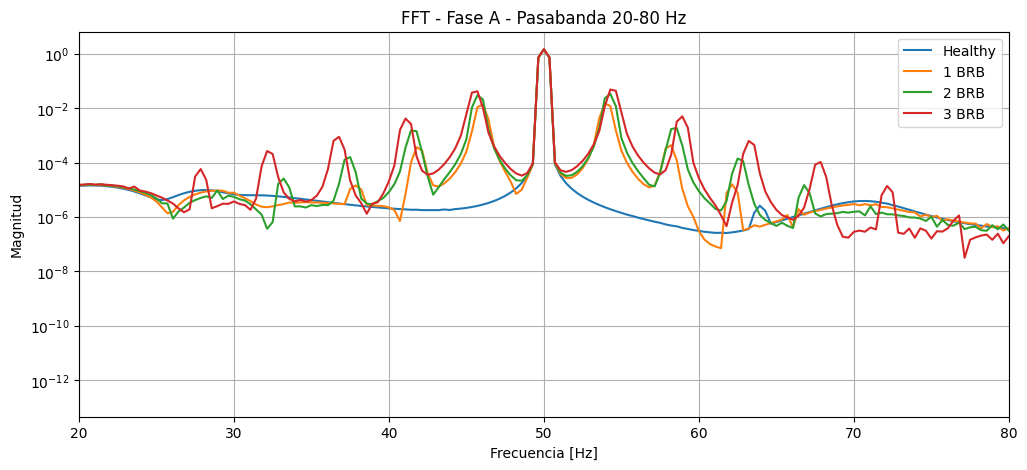

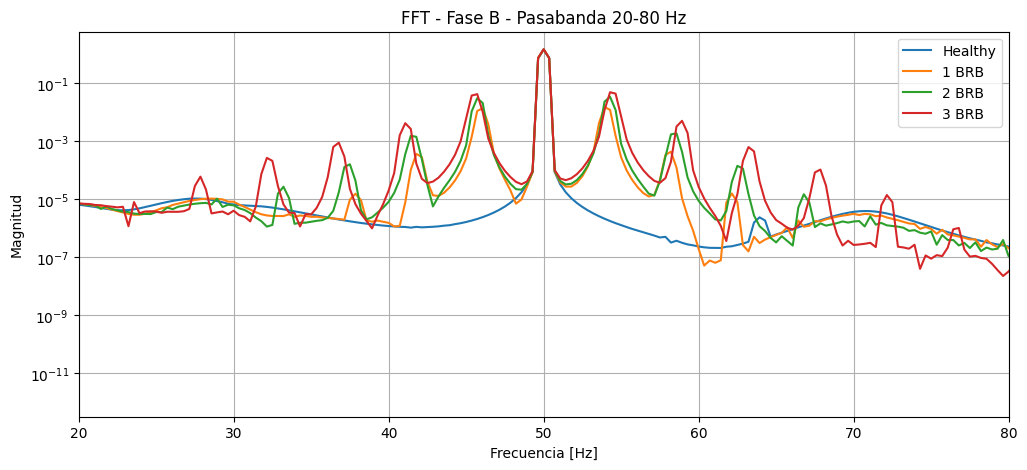

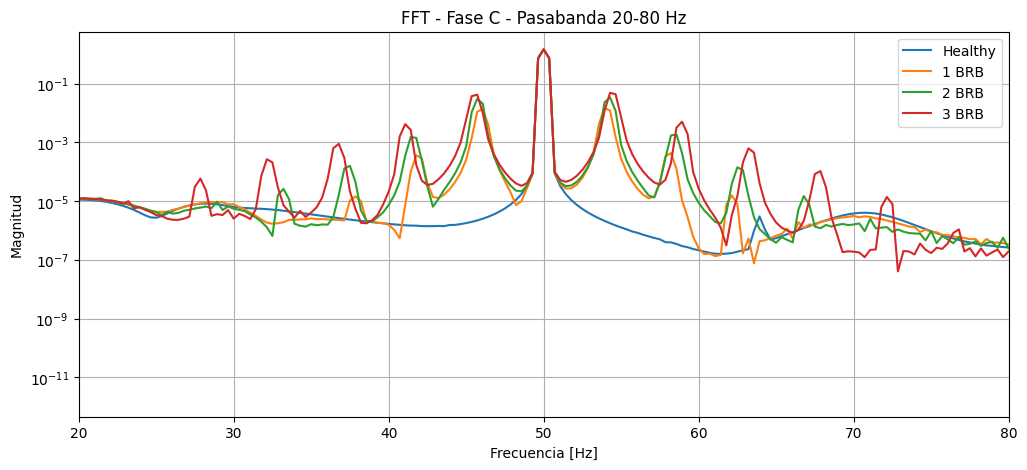

In [48]:
plot_fft_compare(A_H_filt, A_1B_filt, A_2B_filt, A_3B_filt, Fs, "Fase A - Pasabanda 20-80 Hz", xlim=(20, 80))
plot_fft_compare(B_H_filt, B_1B_filt, B_2B_filt, B_3B_filt, Fs, "Fase B - Pasabanda 20-80 Hz", xlim=(20, 80))
plot_fft_compare(C_H_filt, C_1B_filt, C_2B_filt, C_3B_filt, Fs, "Fase C - Pasabanda 20-80 Hz", xlim=(20, 80))

## 11. Welch después del filtrado
PSD de Welch (reutilizando `plot_psd_compare`) sobre las señales filtradas.

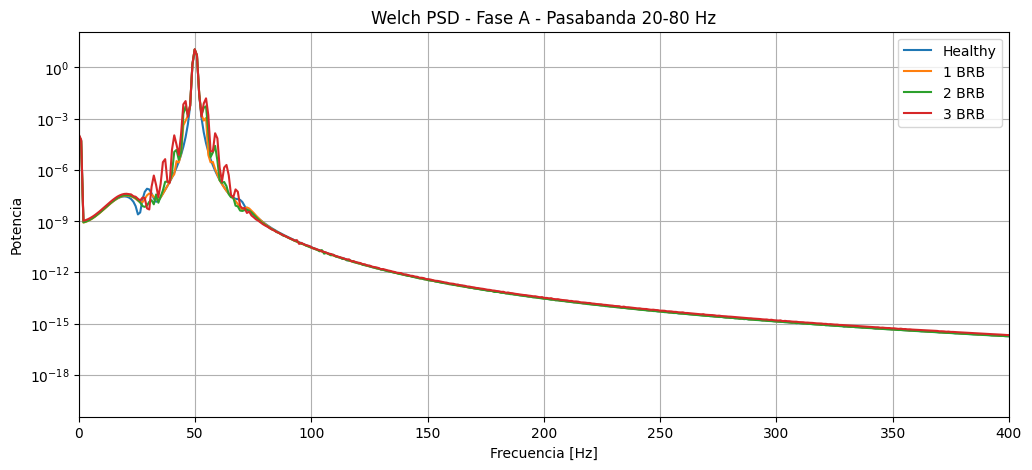

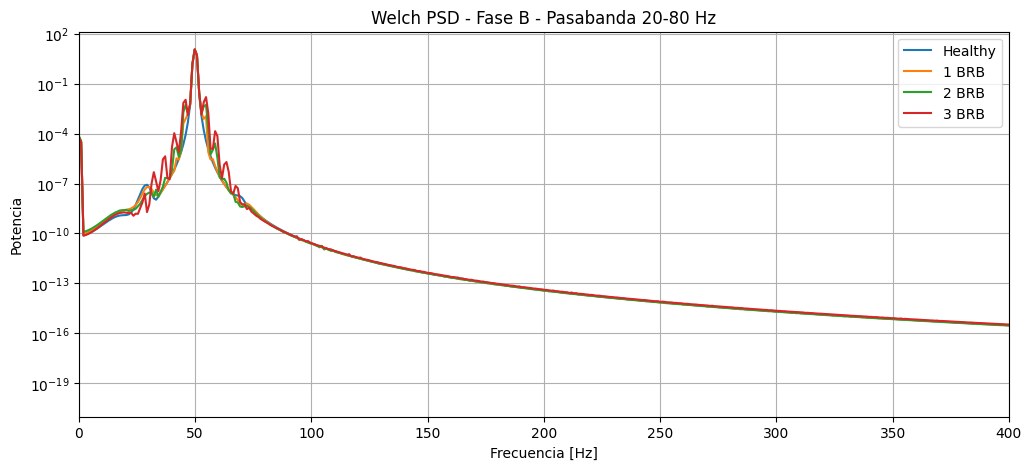

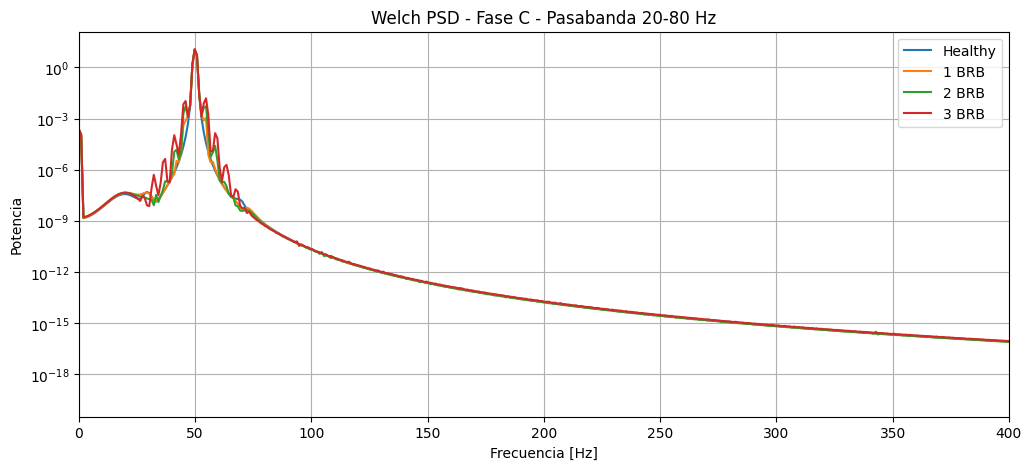

In [49]:
plot_psd_compare(A_H_filt, A_1B_filt, A_2B_filt, A_3B_filt, Fs, "Fase A - Pasabanda 20-80 Hz")
plot_psd_compare(B_H_filt, B_1B_filt, B_2B_filt, B_3B_filt, Fs, "Fase B - Pasabanda 20-80 Hz")
plot_psd_compare(C_H_filt, C_1B_filt, C_2B_filt, C_3B_filt, Fs, "Fase C - Pasabanda 20-80 Hz")

## 12. Features
Extracción de características a partir de las señales filtradas, y los gráficos tal como se usaron en el informe: energía en bandas laterales, Sideband Index (Welch), Fault Index (FFT), entropía espectral y la comparación entre ambos indicadores.

### Funciones auxiliares para las features
`band_energy` integra la PSD entre dos frecuencias (energía de una banda). `fft_peak_in_band` devuelve la amplitud máxima de la FFT dentro de una banda. `fft_count_peaks_in_band` cuenta picos locales que superan un umbral robusto (mediana + n·MAD) calculado dentro de la propia banda, necesario porque las sidebands son ~1000 veces más chicas que el fundamental y un umbral global nunca las detectaría.

In [50]:
def band_energy(f_arr, Pxx_arr, f_low, f_high):
    # integral de Pxx entre f_low y f_high (regla del trapecio)
    mask = (f_arr >= f_low) & (f_arr <= f_high)
    if mask.sum() < 2:
        return 0.0
    return float(np.trapezoid(Pxx_arr[mask], f_arr[mask]))


def fft_peak_in_band(f_arr, X_arr, f_low, f_high):
    # amplitud maxima de la FFT dentro de [f_low, f_high] Hz
    mask = (f_arr >= f_low) & (f_arr <= f_high)
    if mask.sum() == 0:
        return 0.0
    return float(X_arr[mask].max())


def fft_count_peaks_in_band(f_arr, X_arr, f_low, f_high, n_sigma=3.0):
    # cuenta picos locales que superan mediana + n_sigma*MAD dentro de la banda
    mask = (f_arr >= f_low) & (f_arr <= f_high)
    if mask.sum() < 3:
        return 0
    segment = X_arr[mask]
    median = np.median(segment)
    mad = np.median(np.abs(segment - median))
    threshold = median + n_sigma * mad * 1.4826  # 1.4826 para consistencia con sigma
    is_peak = (
        np.concatenate([[False], segment[1:] > segment[:-1]]) &
        np.concatenate([segment[:-1] > segment[1:], [False]])
    )
    return int((is_peak & (segment > threshold)).sum())

### Funcion extract_features
Combina las features clásicas (RMS, curtosis, etc.) con las orientadas a bandas laterales: energía por banda, Sideband Index (Welch), entropía espectral (completa y acotada a 20-80 Hz), y el Fault Index basado en FFT (izquierda, derecha y promedio), junto con la cantidad de picos de sideband detectados.

In [51]:
def extract_features(signal, Fs):

    f, Pxx = compute_psd(signal, Fs)

    peak_idx = np.argmax(Pxx)
    peak_freq = f[peak_idx]
    peak_power = Pxx[peak_idx]

    band_power = np.trapezoid(Pxx, f)
    centroid = np.sum(f * Pxx) / np.sum(Pxx)
    bandwidth = np.sqrt(np.sum(((f - centroid)**2) * Pxx) / np.sum(Pxx))

    rms = np.sqrt(np.mean(signal**2))
    peak = np.max(np.abs(signal))
    crest_factor = peak / rms
    std = np.std(signal)
    skewness = skew(signal)
    kurt = kurtosis(signal)

    # energia del fundamental (45-55 Hz) y de las sidebands de BRB
    # (40-45 Hz y 55-60 Hz, donde caen f1*(1 ± 2s) para deslizamientos tipicos)
    E_fund = band_energy(f, Pxx, 45, 55)
    E_sb_left = band_energy(f, Pxx, 40, 45)
    E_sb_right = band_energy(f, Pxx, 55, 60)
    E_sb_total = E_sb_left + E_sb_right

    # Sideband Index: ratio en dB entre energia de sidebands y energia del fundamental.
    # Muy negativo en healthy, crece monotonamente con la severidad de la falla.
    sideband_index = 10 * np.log10((E_sb_total + 1e-30) / (E_fund + 1e-30))

    # entropia espectral (Shannon) sobre la PSD normalizada como distribucion de probabilidad
    Pxx_norm = Pxx / (Pxx.sum() + 1e-30)
    Pxx_safe = np.where(Pxx_norm > 0, Pxx_norm, 1e-30)
    spectral_entropy = float(-np.sum(Pxx_safe * np.log2(Pxx_safe)))

    # entropia espectral limitada a la banda 20-80 Hz: mas sensible a la redistribucion
    # de energia entre fundamental y sidebands que la entropia sobre el espectro completo
    mask_band = (f >= 20) & (f <= 80)
    Pxx_band = Pxx[mask_band]
    Pxx_band_norm = Pxx_band / (Pxx_band.sum() + 1e-30)
    Pxx_band_safe = np.where(Pxx_band_norm > 0, Pxx_band_norm, 1e-30)
    spectral_entropy_band = float(-np.sum(Pxx_band_safe * np.log2(Pxx_band_safe)))

    # features de FFT: mayor resolucion en frecuencia que Welch, sirve para medir
    # la amplitud puntual del fundamental y de las sidebands
    f_fft, X_fft = compute_fft(signal, Fs)
    fft_fund_amp = fft_peak_in_band(f_fft, X_fft, 48, 52)
    fft_sb_left_amp = fft_peak_in_band(f_fft, X_fft, 40, 45)
    fft_sb_right_amp = fft_peak_in_band(f_fft, X_fft, 55, 60)

    # Fault Index clasico de MCSA en dB: ratio amplitud sideband / fundamental
    fft_fault_index_left_dB = 20 * np.log10(
        (fft_sb_left_amp + 1e-30) / (fft_fund_amp + 1e-30)
    )
    fft_fault_index_right_dB = 20 * np.log10(
        (fft_sb_right_amp + 1e-30) / (fft_fund_amp + 1e-30)
    )
    fft_fault_index_mean_dB = (fft_fault_index_left_dB + fft_fault_index_right_dB) / 2

    # cantidad de picos de sideband detectados por la FFT en cada zona
    fft_n_peaks_left = fft_count_peaks_in_band(f_fft, X_fft, 40, 45)
    fft_n_peaks_right = fft_count_peaks_in_band(f_fft, X_fft, 55, 60)
    fft_n_peaks_sb = fft_n_peaks_left + fft_n_peaks_right

    return {
        "PeakFreq": peak_freq,
        "PeakPower": peak_power,
        "BandPower": band_power,
        "SpectralCentroid": centroid,
        "SpectralBandwidth": bandwidth,
        "RMS": rms,
        "STD": std,
        "Skewness": skewness,
        "Kurtosis": kurt,
        "CrestFactor": crest_factor,
        "Energy_45_55Hz": E_fund,
        "Energy_40_45Hz": E_sb_left,
        "Energy_55_60Hz": E_sb_right,
        "SidebandIndex_dB": sideband_index,
        "SpectralEntropy": spectral_entropy,
        "SpectralEntropy_Band": spectral_entropy_band,
        "FFT_Fund_Amp": fft_fund_amp,
        "FFT_SB_Left_Amp": fft_sb_left_amp,
        "FFT_SB_Right_Amp": fft_sb_right_amp,
        "FFT_FaultIdx_Left_dB": fft_fault_index_left_dB,
        "FFT_FaultIdx_Right_dB": fft_fault_index_right_dB,
        "FFT_FaultIdx_Mean_dB": fft_fault_index_mean_dB,
        "FFT_N_Peaks_SB": fft_n_peaks_sb,
    }

### Tablas de resultados por fase

In [52]:
results_A = pd.DataFrame([
    extract_features(A_H_filt, Fs),
    extract_features(A_1B_filt, Fs),
    extract_features(A_2B_filt, Fs),
    extract_features(A_3B_filt, Fs)
], index=["Healthy","1BRB","2BRB","3BRB"])

print("\nFASE A")
print(results_A)


FASE A
          PeakFreq  PeakPower  BandPower  SpectralCentroid  SpectralBandwidth  \
Healthy  49.804688  11.044830  17.037967         49.999545           0.583524   
1BRB     49.804688  11.137187  17.183037         49.999609           0.585736   
2BRB     49.804688  11.294033  17.438970         50.000037           0.596729   
3BRB     49.804688  11.610947  17.953087         50.001111           0.623774   

              RMS       STD  Skewness  Kurtosis  CrestFactor  ...  \
Healthy  4.127619  4.127615  0.008411 -1.492281     1.819682  ...   
1BRB     4.144462  4.144459  0.008479 -1.492255     1.833030  ...   
2BRB     4.174071  4.174068  0.008526 -1.491073     1.859534  ...   
3BRB     4.234277  4.234273  0.008252 -1.490218     1.807110  ...   

         SidebandIndex_dB  SpectralEntropy  SpectralEntropy_Band  \
Healthy        -56.753726         1.251002              1.250838   
1BRB           -48.925345         1.254329              1.254173   
2BRB           -42.037156         1.

In [53]:
results_B = pd.DataFrame([
    extract_features(B_H_filt, Fs),
    extract_features(B_1B_filt, Fs),
    extract_features(B_2B_filt, Fs),
    extract_features(B_3B_filt, Fs)
], index=["Healthy","1BRB","2BRB","3BRB"])

print("\nFASE B")
print(results_B)


FASE B
          PeakFreq  PeakPower  BandPower  SpectralCentroid  SpectralBandwidth  \
Healthy  49.804688  11.044825  17.037920         49.999749           0.574748   
1BRB     49.804688  11.137182  17.183002         49.999781           0.578381   
2BRB     49.804688  11.294026  17.438946         50.000139           0.592462   
3BRB     49.804688  11.610940  17.953033         50.001340           0.614569   

              RMS       STD  Skewness  Kurtosis  CrestFactor  ...  \
Healthy  4.130115  4.130110 -0.001097 -1.497914     1.767512  ...   
1BRB     4.147025  4.147020 -0.001091 -1.497658     1.770362  ...   
2BRB     4.176776  4.176771 -0.001170 -1.496695     1.785226  ...   
3BRB     4.236266  4.236261 -0.000943 -1.495502     1.740057  ...   

         SidebandIndex_dB  SpectralEntropy  SpectralEntropy_Band  \
Healthy        -56.744247         1.250934              1.250839   
1BRB           -48.924273         1.254272              1.254174   
2BRB           -42.037553         1.

In [54]:
results_C = pd.DataFrame([
    extract_features(C_H_filt, Fs),
    extract_features(C_1B_filt, Fs),
    extract_features(C_2B_filt, Fs),
    extract_features(C_3B_filt, Fs)
], index=["Healthy","1BRB","2BRB","3BRB"])

print("\nFASE C")
print(results_C)


FASE C
          PeakFreq  PeakPower  BandPower  SpectralCentroid  SpectralBandwidth  \
Healthy  49.804688  11.044812  17.038075         49.999075           0.603196   
1BRB     49.804688  11.137169  17.183145         49.999141           0.605212   
2BRB     49.804688  11.294015  17.439085         49.999551           0.616610   
3BRB     49.804688  11.610928  17.953207         50.000616           0.643169   

              RMS       STD  Skewness  Kurtosis  CrestFactor  ...  \
Healthy  4.131936  4.131918 -0.003154 -1.493943     1.809027  ...   
1BRB     4.148174  4.148157 -0.003726 -1.494728     1.744641  ...   
2BRB     4.178019  4.178001 -0.003624 -1.493178     1.778535  ...   
3BRB     4.238594  4.238575 -0.002982 -1.491424     1.804562  ...   

         SidebandIndex_dB  SpectralEntropy  SpectralEntropy_Band  \
Healthy        -56.741814         1.251154              1.250841   
1BRB           -48.922228         1.254481              1.254175   
2BRB           -42.037328         1.

In [55]:
ratio_A = results_A.div(results_A.loc["Healthy"])
print(ratio_A)

ratio_B = results_B.div(results_B.loc["Healthy"])
print(ratio_B)

ratio_C = results_C.div(results_C.loc["Healthy"])
print(ratio_C)

         PeakFreq  PeakPower  BandPower  SpectralCentroid  SpectralBandwidth  \
Healthy       1.0   1.000000   1.000000          1.000000           1.000000   
1BRB          1.0   1.008362   1.008514          1.000001           1.003791   
2BRB          1.0   1.022563   1.023536          1.000010           1.022630   
3BRB          1.0   1.051256   1.053711          1.000031           1.068977   

              RMS       STD  Skewness  Kurtosis  CrestFactor  ...  \
Healthy  1.000000  1.000000  1.000000  1.000000     1.000000  ...   
1BRB     1.004081  1.004081  1.008016  0.999983     1.007335  ...   
2BRB     1.011254  1.011254  1.013581  0.999191     1.021900  ...   
3BRB     1.025840  1.025840  0.981064  0.998618     0.993091  ...   

         SidebandIndex_dB  SpectralEntropy  SpectralEntropy_Band  \
Healthy          1.000000         1.000000              1.000000   
1BRB             0.862064         1.002659              1.002666   
2BRB             0.740694         1.010007       

### Gráfico 1 — Nuevas features espectrales (promedio de las 3 fases)
Barras agrupadas para energía en bandas laterales, Sideband Index y entropía espectral, con el valor anotado sobre cada barra.

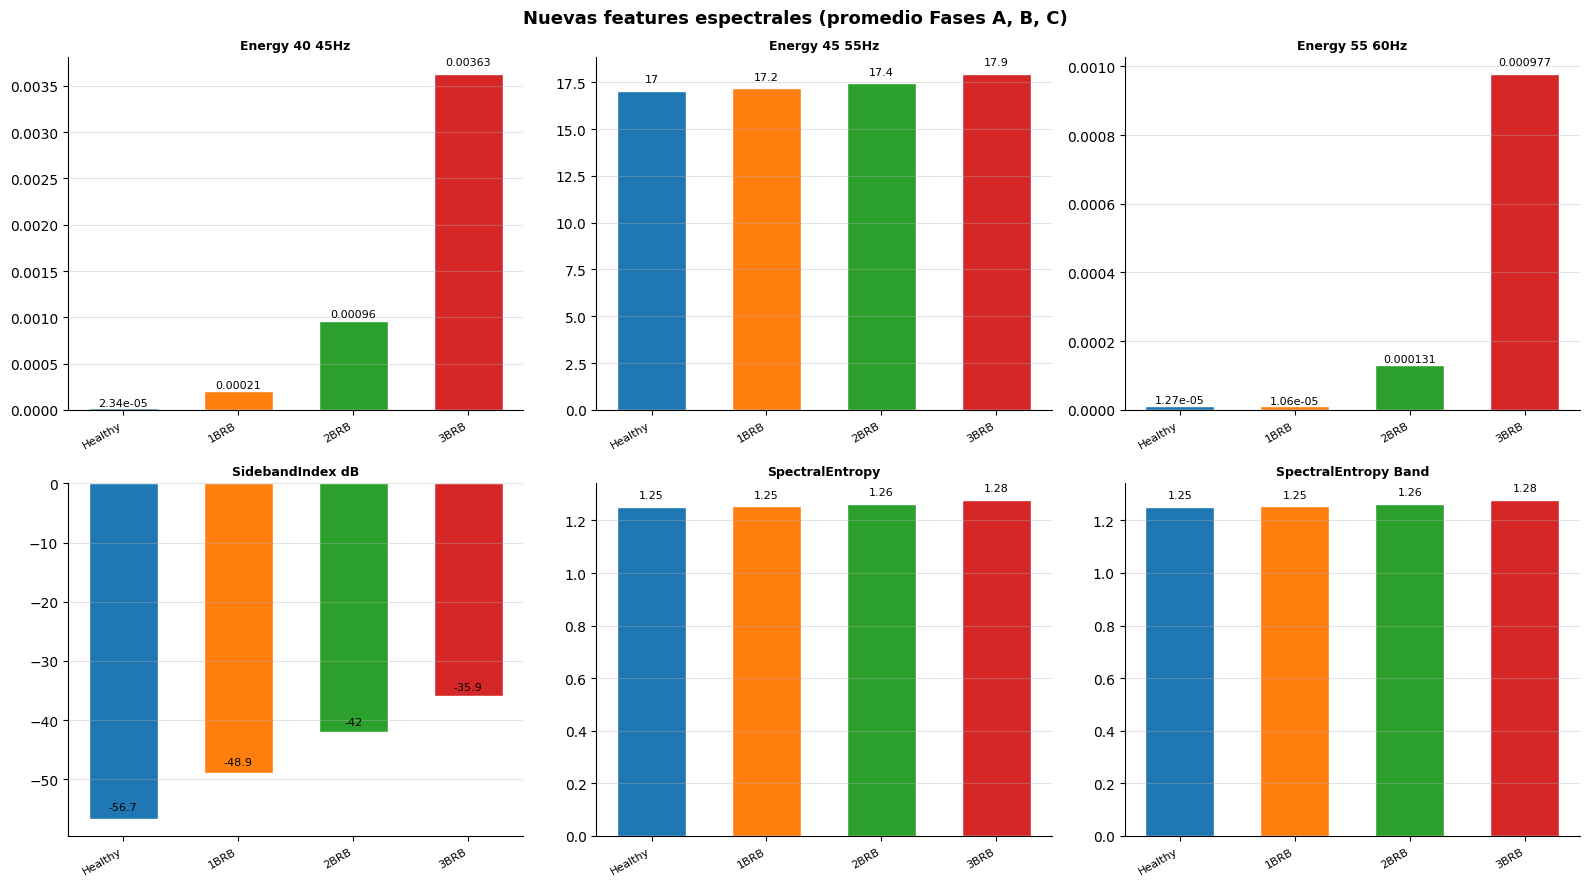

In [56]:
NEW_FEATURES = [
    "Energy_40_45Hz",
    "Energy_45_55Hz",
    "Energy_55_60Hz",
    "SidebandIndex_dB",
    "SpectralEntropy",
    "SpectralEntropy_Band",
]

LABELS = ["Healthy", "1BRB", "2BRB", "3BRB"]
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

results_mean = (results_A + results_B + results_C) / 3

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
fig.suptitle("Nuevas features espectrales (promedio Fases A, B, C)",
             fontsize=13, fontweight="bold")

for ax, feat in zip(axes, NEW_FEATURES):
    vals = results_mean.loc[LABELS, feat].values
    bars = ax.bar(LABELS, vals, color=COLORS, width=0.6, edgecolor="white")

    for bar, v in zip(bars, vals):
        ypos = bar.get_height() + abs(bar.get_height()) * 0.02
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            ypos,
            f"{v:.3g}",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_title(feat.replace("_", " "), fontsize=9, fontweight="bold")
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Gráfico 2 — Ratio normalizado respecto a Healthy
Cuántas veces cambia cada feature respecto de la condición sana.

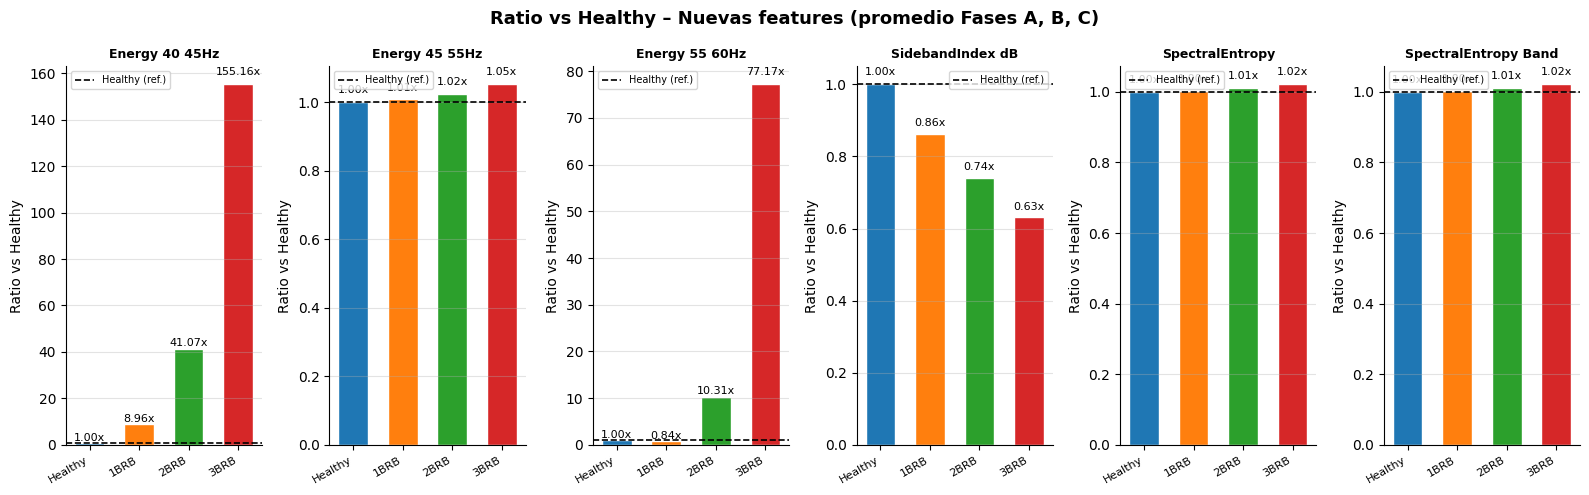

In [57]:
ratio_mean = results_mean.div(results_mean.loc["Healthy"])

fig, axes = plt.subplots(1, len(NEW_FEATURES), figsize=(16, 5))
fig.suptitle("Ratio vs Healthy – Nuevas features (promedio Fases A, B, C)",
             fontsize=13, fontweight="bold")

for ax, feat in zip(axes, NEW_FEATURES):
    vals = ratio_mean.loc[LABELS, feat].values
    bars = ax.bar(LABELS, vals, color=COLORS, width=0.6, edgecolor="white")
    ax.axhline(1.0, color="black", lw=1.2, ls="--", label="Healthy (ref.)")

    for bar, v in zip(bars, vals):
        ypos = bar.get_height() + abs(bar.get_height()) * 0.02
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            ypos,
            f"{v:.2f}x",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_title(feat.replace("_", " "), fontsize=9, fontweight="bold")
    ax.set_ylabel("Ratio vs Healthy")
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=30, ha="right", fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Tabla completa de nuevas features

In [58]:
print("="*60)
print("NUEVAS FEATURES - FASE A")
print("="*60)
print(results_A[NEW_FEATURES].to_string())

print("\n" + "="*60)
print("NUEVAS FEATURES - FASE B")
print("="*60)
print(results_B[NEW_FEATURES].to_string())

print("\n" + "="*60)
print("NUEVAS FEATURES - FASE C")
print("="*60)
print(results_C[NEW_FEATURES].to_string())

print("\n" + "="*60)
print("RATIO VS HEALTHY - PROMEDIO 3 FASES")
print("="*60)
print(ratio_mean[NEW_FEATURES].to_string())

NUEVAS FEATURES - FASE A
         Energy_40_45Hz  Energy_45_55Hz  Energy_55_60Hz  SidebandIndex_dB  SpectralEntropy  SpectralEntropy_Band
Healthy        0.000023       17.037750        0.000013        -56.753726         1.251002              1.250838
1BRB           0.000209       17.181600        0.000011        -48.925345         1.254329              1.254173
2BRB           0.000960       17.431609        0.000131        -42.037156         1.263521              1.263376
3BRB           0.003626       17.931408        0.000977        -35.905143         1.277304              1.277136

NUEVAS FEATURES - FASE B
         Energy_40_45Hz  Energy_45_55Hz  Energy_55_60Hz  SidebandIndex_dB  SpectralEntropy  SpectralEntropy_Band
Healthy        0.000023       17.037750        0.000013        -56.744247         1.250934              1.250839
1BRB           0.000210       17.181604        0.000011        -48.924273         1.254272              1.254174
2BRB           0.000960       17.431608      

### Gráfico 3 — Evolución del Sideband Index y la entropía espectral
Muestra la tendencia monótona con la severidad de la falla (la que va directo al informe).

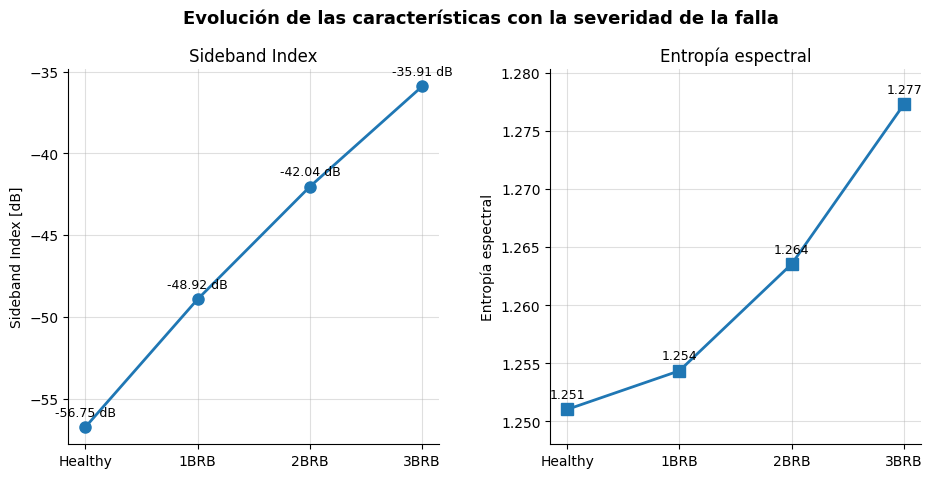

In [66]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))

x = np.arange(len(LABELS))

# =====================================================
# Sideband Index
# =====================================================

vals_sbi = results_mean.loc[LABELS, "SidebandIndex_dB"].values

ax1.plot(x, vals_sbi,
         marker="o",
         linewidth=2,
         markersize=8)

for xi, v in zip(x, vals_sbi):
    ax1.annotate(f"{v:.2f} dB",
                 (xi, v),
                 xytext=(0,8),
                 textcoords="offset points",
                 ha="center",
                 fontsize=9)

ax1.set_xticks(x)
ax1.set_xticklabels(LABELS)
ax1.set_ylabel("Sideband Index [dB]")
ax1.set_title("Sideband Index")
ax1.grid(alpha=0.4)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# =====================================================
# Entropía espectral
# =====================================================

vals_ent = results_mean.loc[LABELS, "SpectralEntropy"].values

ax2.plot(x, vals_ent,
         marker="s",
         linewidth=2,
         markersize=8)

for xi, v in zip(x, vals_ent):
    ax2.annotate(f"{v:.3f}",
                 (xi, v),
                 xytext=(0,8),
                 textcoords="offset points",
                 ha="center",
                 fontsize=9)

# Zoom para apreciar las diferencias
margin = 0.003
ax2.set_ylim(vals_ent.min()-margin,
             vals_ent.max()+margin)

ax2.set_xticks(x)
ax2.set_xticklabels(LABELS)
ax2.set_ylabel("Entropía espectral")
ax2.set_title("Entropía espectral")
ax2.grid(alpha=0.4)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle("Evolución de las características con la severidad de la falla",
             fontsize=13,
             fontweight="bold")

plt.subplots_adjust(top=0.86, wspace=0.30)
plt.show()

### Gráfico 4 — Fault Index (FFT): sideband izquierda, derecha y promedio
Descriptor más cercano al Fault Index estándar de MCSA en la literatura, medido con la alta resolución de la FFT.

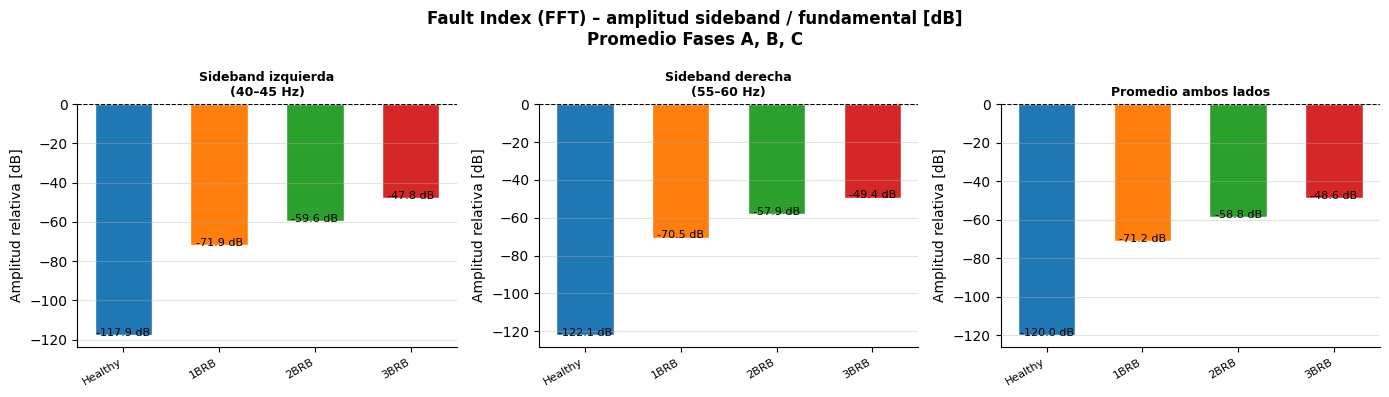

In [60]:
FFT_FEATURES = [
    "FFT_FaultIdx_Left_dB",
    "FFT_FaultIdx_Right_dB",
    "FFT_FaultIdx_Mean_dB",
    "FFT_N_Peaks_SB",
]

results_mean_fft = (results_A + results_B + results_C) / 3

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Fault Index (FFT) – amplitud sideband / fundamental [dB]\n"
             "Promedio Fases A, B, C",
             fontsize=12, fontweight="bold")

subtitles = [
    "Sideband izquierda\n(40–45 Hz)",
    "Sideband derecha\n(55–60 Hz)",
    "Promedio ambos lados",
]

for ax, feat, subtitle in zip(axes, FFT_FEATURES[:3], subtitles):
    vals = results_mean_fft.loc[LABELS, feat].values
    bars = ax.bar(LABELS, vals, color=COLORS, width=0.6, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8, ls="--")

    for bar, v in zip(bars, vals):
        offset = 0.5 if v >= 0 else -1.5
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + offset,
            f"{v:.1f} dB",
            ha="center", va="bottom", fontsize=8
        )

    ax.set_title(subtitle, fontsize=9, fontweight="bold")
    ax.set_ylabel("Amplitud relativa [dB]")
    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels(LABELS, rotation=30, ha="right", fontsize=8)
    ax.grid(axis="y", alpha=0.35)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Gráfico 5 — Número de picos de sideband detectados por la FFT
Un motor sano tiene pocos picos en las zonas laterales; con BRB aparecen múltiples armónicos que la alta resolución de la FFT logra separar.

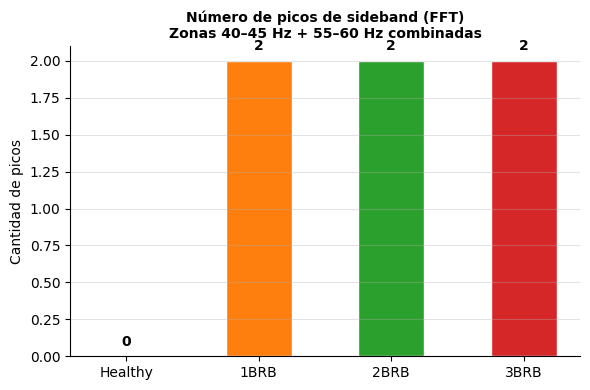

In [61]:
fig, ax = plt.subplots(figsize=(6, 4))
vals = results_mean_fft.loc[LABELS, "FFT_N_Peaks_SB"].values
bars = ax.bar(LABELS, vals, color=COLORS, width=0.5, edgecolor="white")
for bar, v in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.05,
        str(int(round(v))),
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax.set_title("Número de picos de sideband (FFT)\n"
             "Zonas 40–45 Hz + 55–60 Hz combinadas",
             fontsize=10, fontweight="bold")
ax.set_ylabel("Cantidad de picos")
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS)
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Gráfico 6 — Comparación directa: Fault Index (FFT) vs Sideband Index (Welch)
El de FFT usa amplitud puntual (más sensible a picos individuales, más ruidoso); el de Welch usa energía integrada (más suave). Ambos deben crecer monótonamente con la falla.

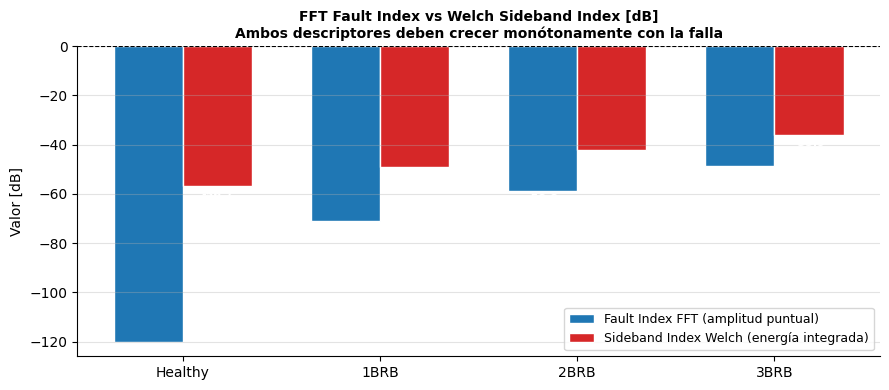

In [62]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(LABELS))
width = 0.35

fi_fft = results_mean_fft.loc[LABELS, "FFT_FaultIdx_Mean_dB"].values
si_welch = results_mean_fft.loc[LABELS, "SidebandIndex_dB"].values

bars1 = ax.bar(x - width/2, fi_fft, width, color="#1f77b4",
               label="Fault Index FFT (amplitud puntual)", edgecolor="white")
bars2 = ax.bar(x + width/2, si_welch, width, color="#d62728",
               label="Sideband Index Welch (energía integrada)", edgecolor="white")

for bar, v in zip(bars1, fi_fft):
    ax.text(bar.get_x() + bar.get_width()/2, v - 1.5,
            f"{v:.1f}", ha="center", va="top", fontsize=8, color="white", fontweight="bold")
for bar, v in zip(bars2, si_welch):
    ax.text(bar.get_x() + bar.get_width()/2, v - 1.5,
            f"{v:.1f}", ha="center", va="top", fontsize=8, color="white", fontweight="bold")

ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel("Valor [dB]")
ax.set_title("FFT Fault Index vs Welch Sideband Index [dB]\n"
             "Ambos descriptores deben crecer monótonamente con la falla",
             fontsize=10, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Tabla de features de FFT

In [63]:
cols_fft = list(FFT_FEATURES) + ["FFT_Fund_Amp", "FFT_SB_Left_Amp", "FFT_SB_Right_Amp"]

print("="*60)
print("FEATURES DE FFT - FASE A")
print("="*60)
print(results_A[cols_fft].to_string())

print("\n" + "="*60)
print("FEATURES DE FFT - FASE B")
print("="*60)
print(results_B[cols_fft].to_string())

print("\n" + "="*60)
print("FEATURES DE FFT - FASE C")
print("="*60)
print(results_C[cols_fft].to_string())

FEATURES DE FFT - FASE A
         FFT_FaultIdx_Left_dB  FFT_FaultIdx_Right_dB  FFT_FaultIdx_Mean_dB  FFT_N_Peaks_SB  FFT_Fund_Amp  FFT_SB_Left_Amp  FFT_SB_Right_Amp
Healthy           -116.526960            -121.472513           -118.999736               0      1.459100         0.000002          0.000001
1BRB               -71.932151             -70.509204            -71.220677               2      1.465134         0.000371          0.000437
2BRB               -59.605446             -57.903721            -58.754584               2      1.475427         0.001544          0.001878
3BRB               -47.789381             -49.385455            -48.587418               2      1.496009         0.006102          0.005078

FEATURES DE FFT - FASE B
         FFT_FaultIdx_Left_dB  FFT_FaultIdx_Right_dB  FFT_FaultIdx_Mean_dB  FFT_N_Peaks_SB  FFT_Fund_Amp  FFT_SB_Left_Amp  FFT_SB_Right_Amp
Healthy           -118.922548            -122.429550           -120.676049               0      1.459100     

## 13. Conclusiones
Las señales en el dominio temporal son prácticamente indistinguibles entre condiciones; las diferencias aparecen recién en el dominio de la frecuencia, como bandas laterales alrededor de los 50 Hz cuya amplitud crece con la cantidad de barras rotas.

Entre las características extraídas, la energía en las bandas laterales, el Sideband Index (Welch) y el Fault Index basado en FFT fueron las más sensibles a la severidad de la falla, mostrando una evolución monotónica clara entre Healthy, 1BRB, 2BRB y 3BRB. La entropía espectral también creció con la falla, aunque de forma más moderada, y el número de picos de sideband detectados por la FFT aumentó consistentemente con la severidad. En cambio, indicadores más globales como RMS, curtosis o frecuencia de pico casi no cambiaron, porque la falla modifica puntualmente el contenido espectral cerca de la fundamental y no la forma general de la señal.